iter 01: best mean J = 0.042762 | elite mean J = 0.052127
iter 02: best mean J = 0.040525 | elite mean J = 0.046964
iter 03: best mean J = 0.040357 | elite mean J = 0.042830
iter 04: best mean J = 0.040357 | elite mean J = 0.041851
iter 05: best mean J = 0.040054 | elite mean J = 0.040503
iter 06: best mean J = 0.039981 | elite mean J = 0.040166
iter 07: best mean J = 0.039923 | elite mean J = 0.040025
iter 08: best mean J = 0.039894 | elite mean J = 0.039924
iter 09: best mean J = 0.039882 | elite mean J = 0.039890
iter 10: best mean J = 0.039879 | elite mean J = 0.039882
iter 11: best mean J = 0.039878 | elite mean J = 0.039879
iter 12: best mean J = 0.039878 | elite mean J = 0.039878
iter 13: best mean J = 0.039878 | elite mean J = 0.039878
iter 14: best mean J = 0.039878 | elite mean J = 0.039878
iter 15: best mean J = 0.039878 | elite mean J = 0.039878
iter 16: best mean J = 0.039878 | elite mean J = 0.039878
iter 17: best mean J = 0.039878 | elite mean J = 0.039878
iter 18: best 

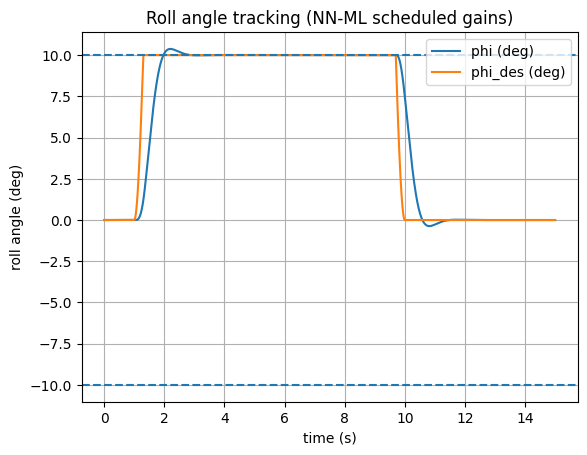

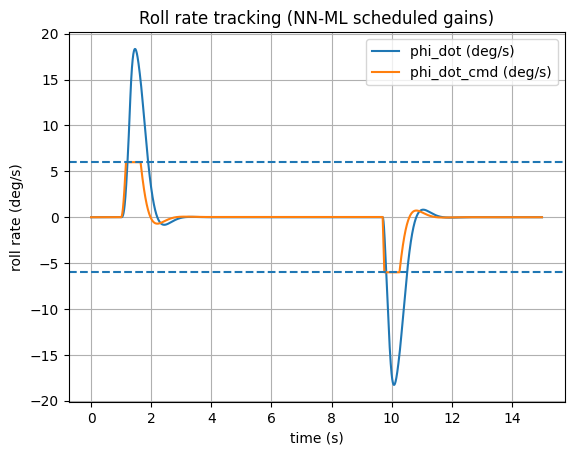

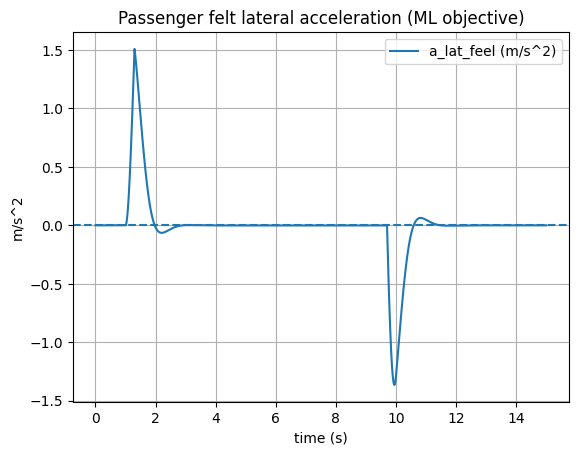

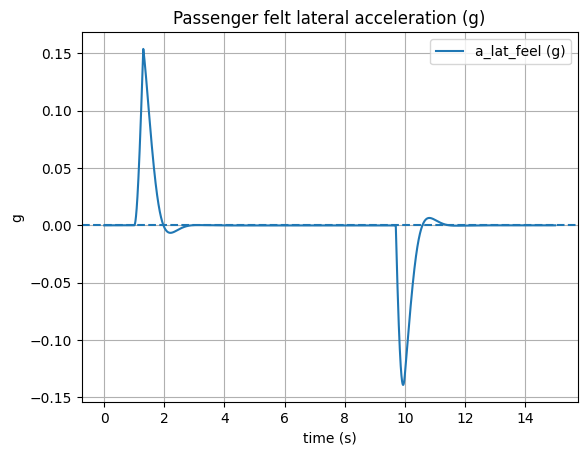

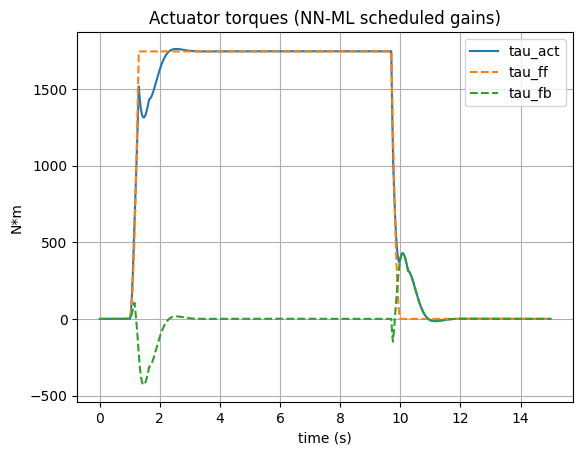

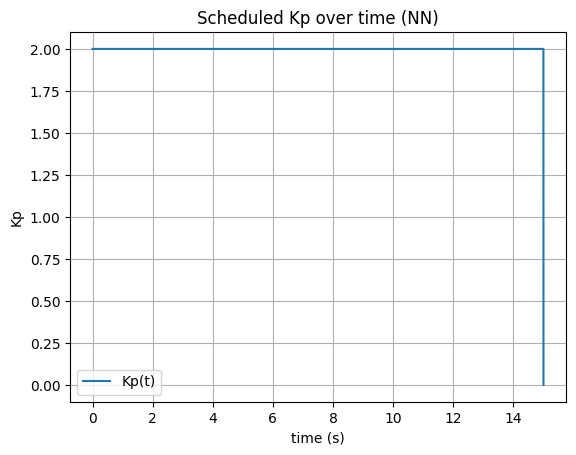

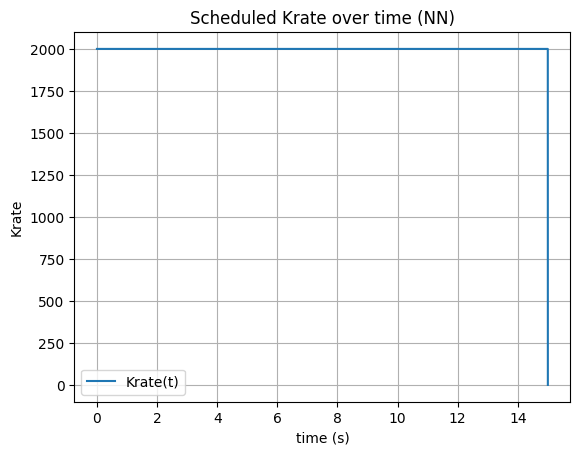

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PLANT / CONTROLLER CONSTANTS
# ============================================================
Iphi = 600.0          # [kg*m^2]
kphi = 10000.0        # [N*m/rad]
cphi = 2000.0         # [N*m*s/rad]

Ki = 0.10                  # keep constant for now
phi_max_deg = 10.0
phi_dot_cmd_max_deg_s = 6.0

dt = 0.002                 # faster training; set 0.001 for final higher-fidelity plots
T = 15.0
g = 9.81

turn_start_time = 1.0
turn_end_time   = 10.0
turn_ramp_time  = 1.0

phi_max = math.radians(phi_max_deg)
phi_dot_cmd_max = math.radians(phi_dot_cmd_max_deg_s)

# ============================================================
# HELPERS
# ============================================================
def clip(x, lo, hi):
    return max(lo, min(hi, x))

def smoothstep01(x):
    x = clip(x, 0.0, 1.0)
    return x*x*(3.0 - 2.0*x)

def sigmoid(x):
    # stable sigmoid
    if x >= 0:
        e = math.exp(-x)
        return 1.0 / (1.0 + e)
    else:
        e = math.exp(x)
        return e / (1.0 + e)

def tanh(x):
    # math.tanh is already stable
    return math.tanh(x)

# ============================================================
# SCENARIO SET (your requested ranges)
# - include |R| = 50 as well
# - train on both signs of R (left/right), but scheduler uses |kappa| so symmetric
# ============================================================
v_set = [5.0, 10.0, 20.0]
R_abs_set = [50.0, 100.0, 200.0, 400.0]
scenario_list = [(v, sgn*Rabs) for v in v_set for Rabs in R_abs_set for sgn in (-1.0, +1.0)]

# ============================================================
# NN GAIN MODEL: 1 hidden layer
# Inputs: [v_norm, kappa_norm, v_norm*kappa_norm]
# Hidden: H units, tanh
# Outputs: 2 scalars -> mapped to bounded gains using sigmoid
# ============================================================
H = 8  # hidden units

# Gain bounds (safety / realism)
Kp_min, Kp_max = 0.3, 2.0
Kr_min, Kr_max = 2000.0, 20000.0

# Normalization scales (so NN sees roughly O(1) values)
V_SCALE = 20.0      # max speed ~20 m/s
KAPPA_SCALE = 1/50  # tightest curvature magnitude ~1/50 = 0.02 1/m

def unpack_theta(theta):
    """
    theta layout:
      W1: (H, D) where D=3
      b1: (H,)
      W2: (2, H)
      b2: (2,)
    total dim = H*3 + H + 2*H + 2 = 6H + 2
    """
    D = 3
    idx = 0
    W1 = theta[idx: idx + H*D].reshape(H, D); idx += H*D
    b1 = theta[idx: idx + H]; idx += H
    W2 = theta[idx: idx + 2*H].reshape(2, H); idx += 2*H
    b2 = theta[idx: idx + 2]; idx += 2
    return W1, b1, W2, b2

def gains_from_theta_nn(theta, v, kappa_abs):
    # Normalize inputs
    v_n = v / V_SCALE
    k_n = kappa_abs / KAPPA_SCALE
    x = np.array([v_n, k_n, v_n * k_n], dtype=float)  # (3,)

    W1, b1, W2, b2 = unpack_theta(theta)

    # Hidden layer
    h = np.tanh(W1 @ x + b1)  # (H,)

    # Output layer (2,)
    y = W2 @ h + b2
    raw_kp, raw_kr = float(y[0]), float(y[1])

    # Map to bounds
    Kp = Kp_min + (Kp_max - Kp_min) * sigmoid(raw_kp)
    Krate = Kr_min + (Kr_max - Kr_min) * sigmoid(raw_kr)
    return Kp, Krate

# ============================================================
# SIMULATOR (single scenario)
# objective: mean(|a_lat_feel|), where a_lat_feel = g*(phi_des - phi)
# ============================================================
def simulate(theta, v, R, return_traces=False):
    N = int(T/dt) + 1
    t = np.linspace(0.0, T, N)

    phi = np.zeros(N)
    phi_dot = np.zeros(N)

    phi_des = np.zeros(N)
    phi_dot_cmd = np.zeros(N)

    a_lat_feel = np.zeros(N)
    ay = np.zeros(N)
    kappa_arr = np.zeros(N)

    tau_ff = np.zeros(N)
    tau_fb = np.zeros(N)
    tau_act = np.zeros(N)

    Kp_used = np.zeros(N)
    Krate_used = np.zeros(N)

    e_int = 0.0

    for i in range(N-1):
        ti = t[i]

        # curvature ramp in / hold / ramp out
        if ti < turn_start_time:
            s = 0.0
        elif ti < turn_start_time + turn_ramp_time:
            xi = (ti - turn_start_time) / turn_ramp_time
            s = smoothstep01(xi)
        elif ti < turn_end_time - turn_ramp_time:
            s = 1.0
        elif ti < turn_end_time:
            xi = (ti - (turn_end_time - turn_ramp_time)) / turn_ramp_time
            s = 1.0 - smoothstep01(xi)
        else:
            s = 0.0

        kappa = 0.0 if abs(R) < 1e-9 else (s / R)   # signed curvature
        kappa_arr[i] = kappa
        kappa_abs = abs(kappa)

        ay_i = v*v*kappa
        ay[i] = ay_i

        # desired lean (comfort)
        phi_des_i = -math.atan(ay_i / g)
        phi_des_i = clip(phi_des_i, -phi_max, phi_max)
        phi_des[i] = phi_des_i

        # comfort metric (reduced-model consistent)
        a_lat_feel[i] = g * (phi_des_i - phi[i])

        # NN-scheduled gains
        Kp, Krate = gains_from_theta_nn(theta, v, kappa_abs)
        Kp_used[i] = Kp
        Krate_used[i] = Krate

        # PI outer loop -> roll-rate command
        e = phi_des_i - phi[i]
        phi_dot_cmd_unsat = Kp * e + Ki * e_int
        phi_dot_cmd_i = clip(phi_dot_cmd_unsat, -phi_dot_cmd_max, phi_dot_cmd_max)
        phi_dot_cmd[i] = phi_dot_cmd_i

        # anti-windup
        saturated = abs(phi_dot_cmd_unsat - phi_dot_cmd_i) > 1e-12
        if (not saturated) or ((phi_dot_cmd_i == phi_dot_cmd_max and e < 0.0) or (phi_dot_cmd_i == -phi_dot_cmd_max and e > 0.0)):
            e_int += e * dt

        # feedforward + feedback torque
        tau_ff_i = kphi * phi_des_i
        tau_fb_i = Krate * (phi_dot_cmd_i - phi_dot[i])
        tau_act_i = tau_ff_i + tau_fb_i

        tau_ff[i] = tau_ff_i
        tau_fb[i] = tau_fb_i
        tau_act[i] = tau_act_i

        # plant: I*phi_ddot + c*phi_dot + k*phi = tau_act
        phi_ddot_i = (tau_act_i - cphi*phi_dot[i] - kphi*phi[i]) / Iphi
        phi_dot[i+1] = phi_dot[i] + phi_ddot_i * dt
        phi[i+1] = phi[i] + phi_dot[i+1] * dt

    J = float(np.mean(np.abs(a_lat_feel)))

    if not return_traces:
        return J

    return J, dict(
        t=t, phi=phi, phi_dot=phi_dot, phi_des=phi_des, phi_dot_cmd=phi_dot_cmd,
        a_lat_feel=a_lat_feel, ay=ay, kappa=kappa_arr,
        tau_ff=tau_ff, tau_fb=tau_fb, tau_act=tau_act,
        Kp_used=Kp_used, Krate_used=Krate_used,
        v=v, R=R
    )

# ============================================================
# EVALUATION ACROSS MULTIPLE (v,R) SCENARIOS
# ============================================================
def evaluate(theta, scenarios=scenario_list):
    Js = []
    for (v, R) in scenarios:
        Js.append(simulate(theta, v, R, return_traces=False))
    return float(np.mean(Js))

# ============================================================
# CROSS-ENTROPY METHOD (CEM) OPTIMIZER ON theta
# ============================================================
def cem_optimize(
        n_iter=45,
        pop_size=90,
        elite_frac=0.2,
        init_std=0.7,
        seed=3
):
    rng = np.random.default_rng(seed)

    dim = 6*H + 2  # (H*3 + H + 2*H + 2)
    mean = np.zeros(dim)
    std = np.ones(dim) * init_std
    n_elite = max(1, int(pop_size * elite_frac))

    best_theta = mean.copy()
    best_J = float("inf")

    for it in range(n_iter):
        thetas = rng.normal(loc=mean, scale=std, size=(pop_size, dim))
        Js = np.array([evaluate(th) for th in thetas], dtype=float)

        elite_idx = np.argsort(Js)[:n_elite]
        elite = thetas[elite_idx]
        elite_J = Js[elite_idx]

        # update sampling distribution
        mean = elite.mean(axis=0)
        std = elite.std(axis=0) + 1e-6

        # best tracking
        if elite_J[0] < best_J:
            best_J = float(elite_J[0])
            best_theta = elite[0].copy()

        print(f"iter {it+1:02d}: best mean J = {best_J:.6f} | elite mean J = {elite_J.mean():.6f}")

    return best_theta, best_J

# ============================================================
# TRAIN
# ============================================================
best_theta, best_J = cem_optimize()

print("\nBest mean objective over scenarios (mean |a_lat_feel|):", best_J)

# Print per-scenario costs (so you can see worst cases)
print("\nPer-scenario J (mean |a_lat_feel|):")
worst = (-1.0, None)
for (v, R) in scenario_list:
    J = simulate(best_theta, v, R, return_traces=False)
    print(f"  v={v:>4.1f} m/s, R={R:>6.1f} m : J={J:.6f}")
    if J > worst[0]:
        worst = (J, (v, R))
print("\nWorst scenario:", worst[1], "with J=", worst[0])

# ============================================================
# VALIDATE + PLOT (plot worst scenario automatically)
# ============================================================
v_plot, R_plot = worst[1]
J_plot, tr = simulate(best_theta, v_plot, R_plot, return_traces=True)
print(f"\nValidation plot scenario: v={v_plot} R={R_plot} | J={J_plot:.6f}")

t = tr["t"]

plt.figure()
plt.plot(t, np.degrees(tr["phi"]), label="phi (deg)")
plt.plot(t, np.degrees(tr["phi_des"]), label="phi_des (deg)")
plt.axhline(phi_max_deg, linestyle="--")
plt.axhline(-phi_max_deg, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("roll angle (deg)")
plt.title("Roll angle tracking (NN-ML scheduled gains)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, np.degrees(tr["phi_dot"]), label="phi_dot (deg/s)")
plt.plot(t, np.degrees(tr["phi_dot_cmd"]), label="phi_dot_cmd (deg/s)")
plt.axhline(phi_dot_cmd_max_deg_s, linestyle="--")
plt.axhline(-phi_dot_cmd_max_deg_s, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("roll rate (deg/s)")
plt.title("Roll rate tracking (NN-ML scheduled gains)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["a_lat_feel"], label="a_lat_feel (m/s^2)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("m/s^2")
plt.title("Passenger felt lateral acceleration (ML objective)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["a_lat_feel"]/g, label="a_lat_feel (g)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("g")
plt.title("Passenger felt lateral acceleration (g)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["tau_act"], label="tau_act")
plt.plot(t, tr["tau_ff"], label="tau_ff", linestyle="--")
plt.plot(t, tr["tau_fb"], label="tau_fb", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("N*m")
plt.title("Actuator torques (NN-ML scheduled gains)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["Kp_used"], label="Kp(t)")
plt.xlabel("time (s)")
plt.ylabel("Kp")
plt.title("Scheduled Kp over time (NN)")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["Krate_used"], label="Krate(t)")
plt.xlabel("time (s)")
plt.ylabel("Krate")
plt.title("Scheduled Krate over time (NN)")
plt.legend()
plt.grid(True)

plt.show()


Scenario: v=15.0 m/s, R=-100.0 m
Mean |felt lateral accel| = 0.078178 m/s^2 (0.007969 g)


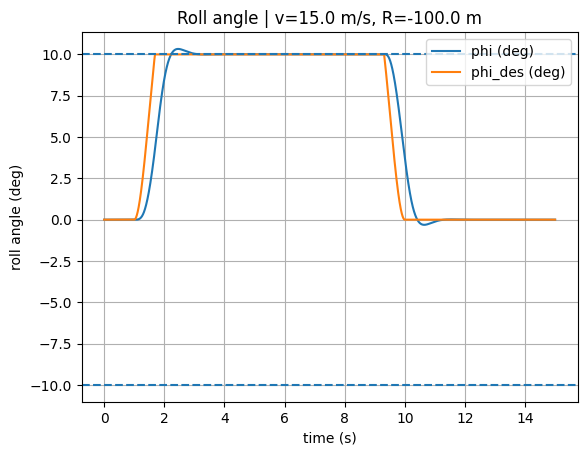

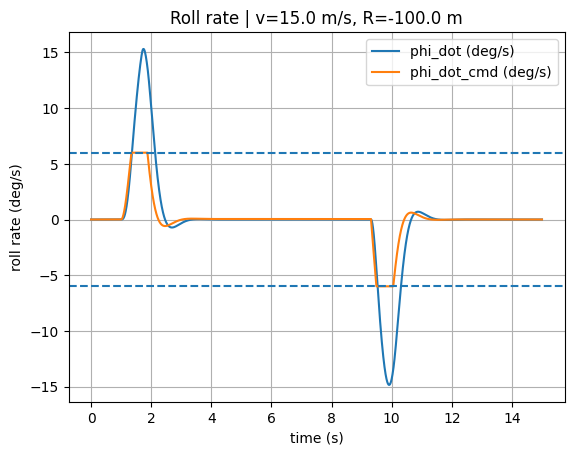

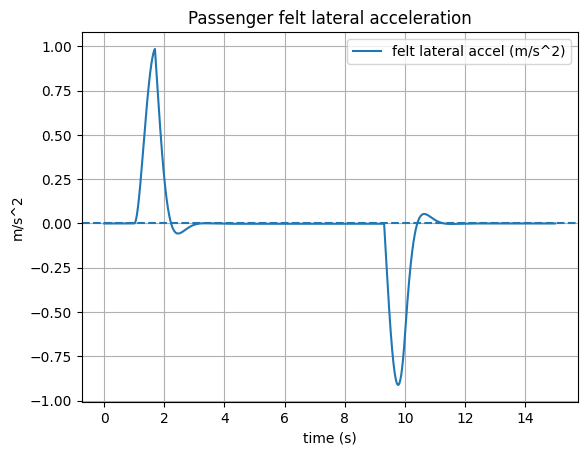

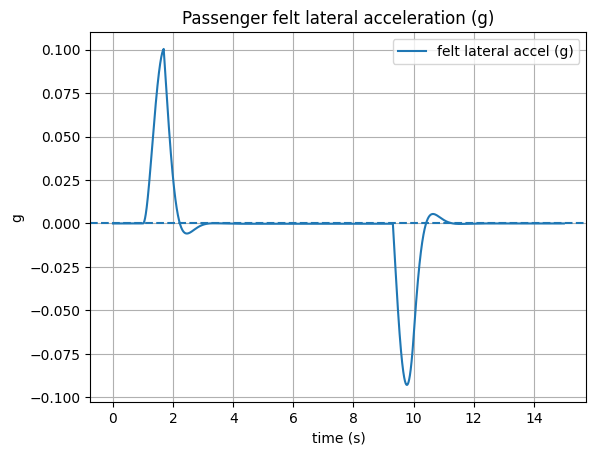

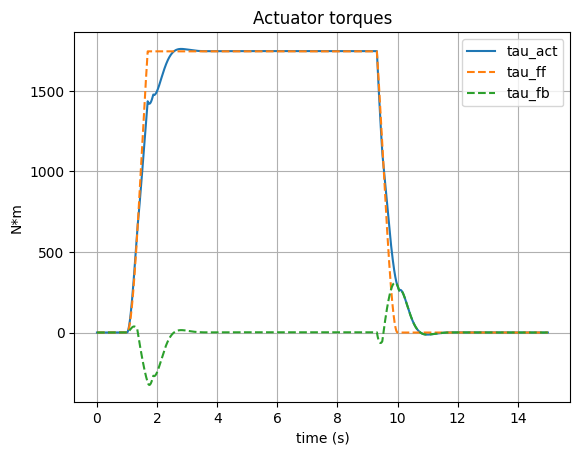

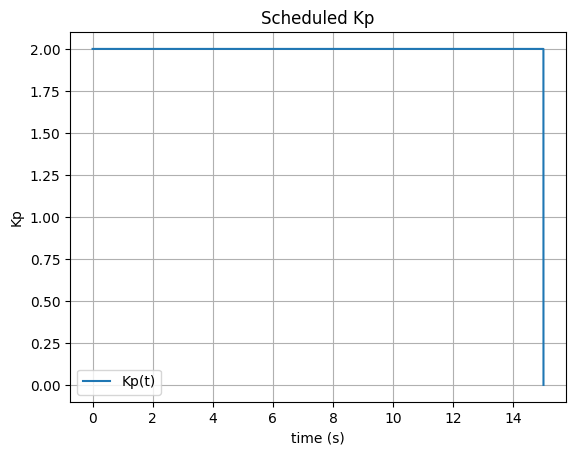

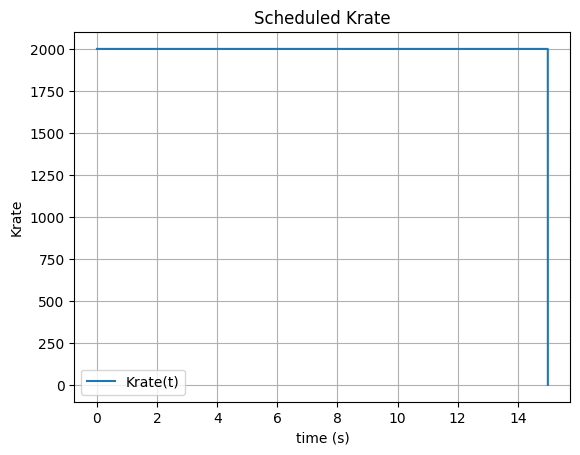

In [2]:
# ============================================================
# USER INPUT (change only these)
# ============================================================
v_input = 15.0     # m/s
R_input = -100.0   # m (negative = right turn, positive = left turn)

# ============================================================
# RUN SIMULATION
# ============================================================
J, tr = simulate(best_theta, v_input, R_input, return_traces=True)

print(f"Scenario: v={v_input} m/s, R={R_input} m")
print(f"Mean |felt lateral accel| = {J:.6f} m/s^2 ({J/9.81:.6f} g)")

t = tr["t"]

# ============================================================
# PLOTS
# ============================================================

# --- Roll angle ---
plt.figure()
plt.plot(t, np.degrees(tr["phi"]), label="phi (deg)")
plt.plot(t, np.degrees(tr["phi_des"]), label="phi_des (deg)")
plt.axhline(10.0, linestyle="--")
plt.axhline(-10.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("roll angle (deg)")
plt.title(f"Roll angle | v={v_input} m/s, R={R_input} m")
plt.legend()
plt.grid(True)

# --- Roll rate ---
plt.figure()
plt.plot(t, np.degrees(tr["phi_dot"]), label="phi_dot (deg/s)")
plt.plot(t, np.degrees(tr["phi_dot_cmd"]), label="phi_dot_cmd (deg/s)")
plt.axhline(6.0, linestyle="--")
plt.axhline(-6.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("roll rate (deg/s)")
plt.title(f"Roll rate | v={v_input} m/s, R={R_input} m")
plt.legend()
plt.grid(True)

# --- Passenger comfort metric ---
plt.figure()
plt.plot(t, tr["a_lat_feel"], label="felt lateral accel (m/s^2)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("m/s^2")
plt.title("Passenger felt lateral acceleration")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["a_lat_feel"] / 9.81, label="felt lateral accel (g)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("g")
plt.title("Passenger felt lateral acceleration (g)")
plt.legend()
plt.grid(True)

# --- Actuator torques ---
plt.figure()
plt.plot(t, tr["tau_act"], label="tau_act")
plt.plot(t, tr["tau_ff"], label="tau_ff", linestyle="--")
plt.plot(t, tr["tau_fb"], label="tau_fb", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("N*m")
plt.title("Actuator torques")
plt.legend()
plt.grid(True)

# --- Scheduled gains ---
plt.figure()
plt.plot(t, tr["Kp_used"], label="Kp(t)")
plt.xlabel("time (s)")
plt.ylabel("Kp")
plt.title("Scheduled Kp")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(t, tr["Krate_used"], label="Krate(t)")
plt.xlabel("time (s)")
plt.ylabel("Krate")
plt.title("Scheduled Krate")
plt.legend()
plt.grid(True)

plt.show()
